In this notebook, we demonstrate usage of SpotSweeper_py on a public VisiumHD dataset. Specifically, the sample is taken from a human female breast cancer FFPE tissue block. The data summary could be obtained here: https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-human-breast-cancer-ffpe-if/

In [30]:
from typing import Optional, Sequence
import matplotlib.pyplot as plt

# HELPER FUNCTIONS USED LATER
def plot_qc_metric_with_outliers(
    adata,
    sample_id: str = "region",
    sample: Optional[str] = None,
    metric: str = "total_counts",
    outliers: str = "qc_outlier",
    point_size: float = 2,
    colors: Sequence[str] = ("white", "black"),
    stroke: float = 1.0,
    coord_key: str = "spatial",
    title_prefix: str = "QC Metric",
    title: Optional[str] = None,  # customizable title
):
    import pandas as pd
    import numpy as np
    from matplotlib.colors import LinearSegmentedColormap

    # Select sample
    if sample_id is None or sample_id not in adata.obs.columns:
        adata_sub = adata.copy()  # use all spots (single sample)
    else:
        if sample is None:
            sample = adata.obs[sample_id].unique()[0]
        mask = np.array(adata.obs[sample_id] == sample)
        adata_sub = adata[mask].copy()

    # Build dataframe
    coords = np.array(adata_sub.obsm[coord_key])
    df = pd.DataFrame(coords, columns=["x", "y"], index=adata_sub.obs_names)
    df[metric] = adata_sub.obs[metric].astype(float)
    df["outlier"] = adata_sub.obs[outliers].astype(bool)
    
    # Condition: nonzero counts & outliers
    df["color_condition"] = (df[metric] > 0) & (df["outlier"])

    # Color scale
    cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

    # Base plot
    plt.figure(figsize=(6, 6))
    base = plt.scatter(
        df["x"], df["y"],
        c=df[metric], cmap=cmap, s=point_size**2,
        linewidths=0, rasterized=True
    )

    # Highlighted overlay
    highlighted = df[df["color_condition"]]
    print(f"Colored = {len(highlighted):,} / {len(df):,} "
          f"({len(highlighted)/len(df)*100:.2f}%)")

    plt.scatter(
        highlighted["x"], highlighted["y"],
        facecolors="none",
        edgecolors="red",
        linewidths=stroke * 1.5,
        alpha=0.8,
        s=(point_size * 0.9) ** 2,
    )

    # Axes and labels
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.colorbar(base, label=metric)

    # Title: use custom if provided
    if title is not None:
        plt.title(title)
    else:
        plt.title(f"Global {title_prefix}: {metric} ({sample})")

    plt.xlabel("x")
    plt.ylabel("y")

        # Legend for outliers vs non-outliers
    import matplotlib.lines as mlines
    non_out = mlines.Line2D(
        [], [], marker="o", linestyle="None",
        markerfacecolor="none", markeredgecolor="black",
        markersize=6, label="Non-outlier",
    )
    out = mlines.Line2D(
        [], [], marker="o", linestyle="None",
        markerfacecolor="none", markeredgecolor="red",
        markersize=6, label="Outlier",
    )
    plt.legend(handles=[non_out, out], loc="upper right")
    
    plt.tight_layout()
    return plt

To get started with the analysis, we process the dataset and convert into AnnData object.

In [31]:
from spatialdata_io import visium_hd
import spatialdata as sd

sdata = visium_hd("/dcs04/hicks/data/xchen5_temp/VisiumHD/", dataset_id = "Visium_HD_Human_Breast_Cancer_FFPE", fullres_image_file = "outs/spatial/tissue_hires_image.png")


/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


We demonstrate the usage of SpotSweeper_py on **8um** bins first.

We first visualize the tissue section with respect to a selected QC metric (using pip-installable package **visiumhd-utils**). Then, we apply SpotSweeper and present its results, demonstrating the effect of the algorithm.

**Global QC: Summary Statistics**

In [32]:
import visiumhd_utils.qc_plot as qp
qp.compute_qc_metrics(sdata, bin_size=8, mito_prefix="MT-")
adata = sdata.tables["square_008um"]

import numpy as np
from scipy.stats import median_abs_deviation

def is_outlier(vec, nmads=3, log=False, direction='both'):
    arr = np.log1p(vec) if log else np.asarray(vec)
    med = np.nanmedian(arr)
    mad = median_abs_deviation(arr, nan_policy='omit')
    lower = med - nmads * mad
    upper = med + nmads * mad
    if direction == 'lower':
        return arr < lower
    elif direction == 'higher':
        return arr > upper
    else:
        return (arr < lower) | (arr > upper)
    
adata.obs['low_counts_outlier'] = is_outlier(adata.obs['total_counts'], direction='lower')
adata.obs['low_log_counts_outlier'] = is_outlier(adata.obs['log_total_counts'], direction='lower')
adata.obs['high_mt_outlier']   = is_outlier(adata.obs['pct_counts_mt'], direction='higher')
adata.obs['low_genes_outlier'] = is_outlier(adata.obs['n_genes_by_counts'], direction='lower')

# combine into one global flag
adata.obs['all_metrics_outlier'] = (
    adata.obs['low_counts_outlier'] | adata.obs['low_log_counts_outlier'] | adata.obs['high_mt_outlier'] | adata.obs['low_genes_outlier']
)

print(adata.obs['low_counts_outlier'].value_counts())
print(adata.obs['low_log_counts_outlier'].value_counts())
print(adata.obs['high_mt_outlier'].value_counts())
print(adata.obs['low_genes_outlier'].value_counts())
print(adata.obs['all_metrics_outlier'].value_counts())

low_counts_outlier
False    663857
Name: count, dtype: int64
low_log_counts_outlier
False    649646
True      14211
Name: count, dtype: int64
high_mt_outlier
False    636623
True      27234
Name: count, dtype: int64
low_genes_outlier
False    663857
Name: count, dtype: int64
all_metrics_outlier
False    623103
True      40754
Name: count, dtype: int64


**Total Counts**

Spotplot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using 'datashader' backend with 'max' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   


/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using the datashader reduction "max". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


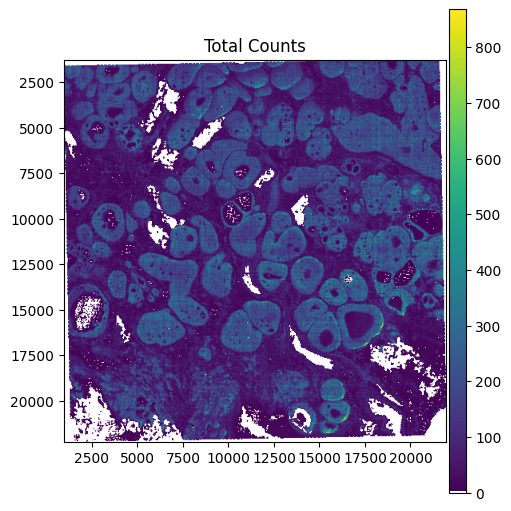

In [33]:
import visiumhd_utils.qc_plot as qp
qp.compute_qc_metrics(sdata, bin_size=8, mito_prefix="MT-")
qp.plot_qc_metrics(sdata, "Visium_HD_Human_Breast_Cancer_FFPE", "total_counts", bin_size = 8, figsize=(5,5), title = "Total Counts")

Global QC Plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Colored = 0 / 663,857 (0.00%)


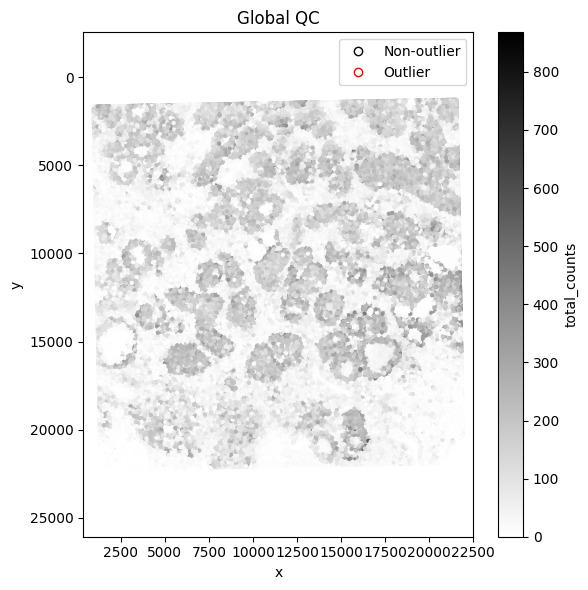

In [34]:
plot_qc_metric_with_outliers(
    adata=adata,
    sample_id="region",
    sample="Visium_HD_Human_Breast_Cancer_FFPE_square_008um",
    metric="total_counts",
    outliers="low_counts_outlier",       # boolean column
    point_size=3,
    colors=("white", "black"),  # background color gradient
    stroke=0.8,
    title="Global QC"
)
plt.show()

Note no outliers flagged!

Then, we apply SpotSweeper on the 8um bins, with respect to the total counts metric. In the figure, the red spots are spots that are flagged as low outliers with respect to the total counts metric.  
Runtime on a compute node: 35.7 seconds.

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<module 'matplotlib.pyplot' from '/jhpce/shared/jhpce/core/python/3.9.14/lib/python3.9/site-packages/matplotlib/pyplot.py'>

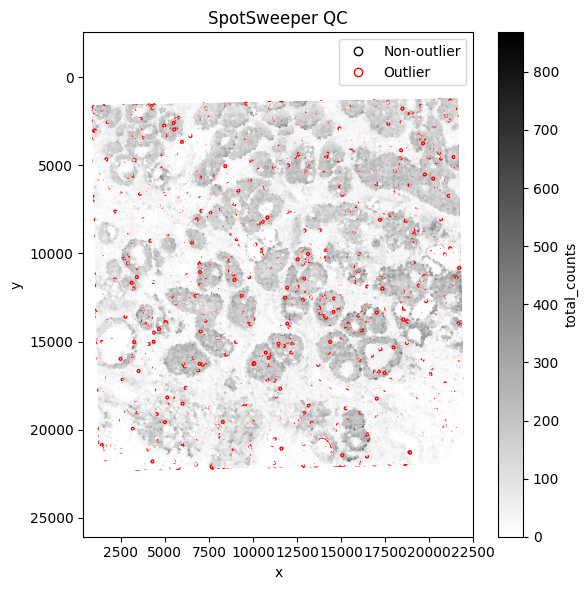

In [35]:
import spotsweeper.local_outliers as lo
import spotsweeper.plot_QC as plot_QC

adata = sdata.tables["square_008um"]
lo.local_outliers(adata, metric = "total_counts", n_neighbors = 48, sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(adata,"region", metric = "total_counts", outliers="total_counts_outliers", title="SpotSweeper QC", legend=True, ring_overlay=False) # plot outliers

In [36]:
col = "total_counts_outliers"
print(adata.obs[col].value_counts())

total_counts_outliers
False    656840
True       7017
Name: count, dtype: int64


Flagged percentage: 7017/(7017+656840) = 1.06%

We then repeat for log total counts, number of genes by counts, and % mitochondrial counts metrics.

**Log Total Counts**

Spotplot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using 'datashader' backend with 'max' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   


/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using the datashader reduction "max". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


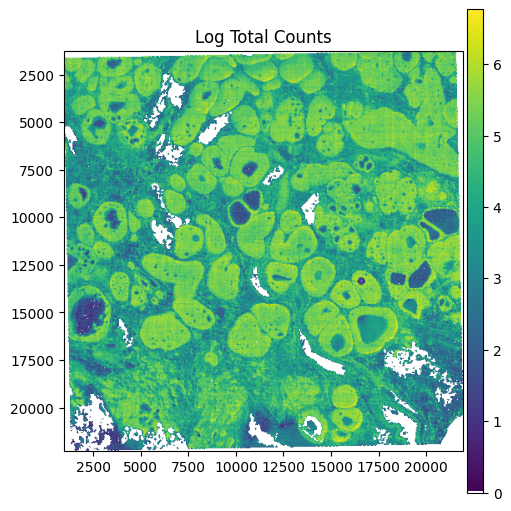

In [37]:
qp.plot_qc_metrics(sdata, "Visium_HD_Human_Breast_Cancer_FFPE", "log_total_counts", bin_size = 8, figsize=(5,5), title = "Log Total Counts")

Global QC Plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Colored = 12,828 / 663,857 (1.93%)


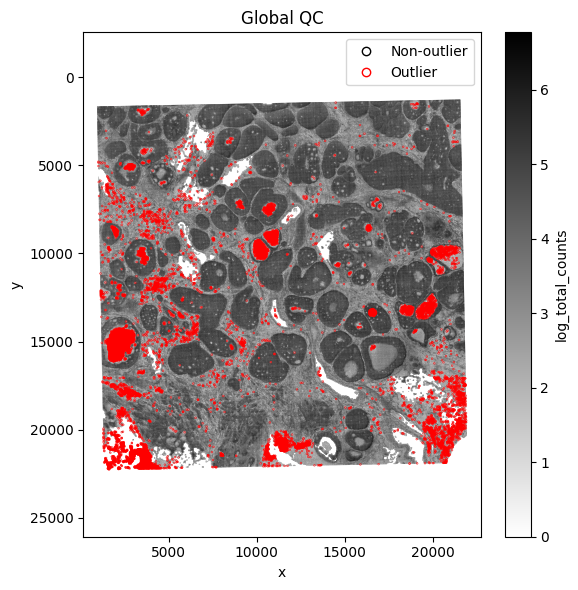

In [38]:
plot_qc_metric_with_outliers(
    adata=adata,
    sample_id="region",
    sample="Visium_HD_Human_Breast_Cancer_FFPE_square_008um",
    metric="log_total_counts",
    outliers="low_log_counts_outlier",       # boolean column
    point_size=0.5,
    colors=("white", "black"),  # background color gradient
    stroke=0.8,
    title="Global QC"
)
plt.show()

SpotSweeper Plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<module 'matplotlib.pyplot' from '/jhpce/shared/jhpce/core/python/3.9.14/lib/python3.9/site-packages/matplotlib/pyplot.py'>

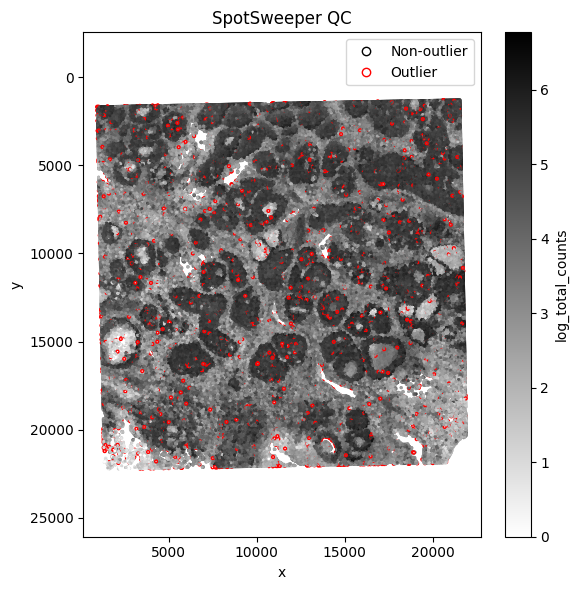

In [39]:
import spotsweeper.local_outliers as lo
import spotsweeper.plot_QC as plot_QC

lo.local_outliers(adata, metric = "log_total_counts", n_neighbors = 48, sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(adata,"region", metric = "log_total_counts", outliers="log_total_counts_outliers", title="SpotSweeper QC", legend=True, ring_overlay=False) # plot outliers

In [40]:
col = "log_total_counts_outliers"
print(adata.obs[col].value_counts())

log_total_counts_outliers
False    653306
True      10551
Name: count, dtype: int64


Flagged percentage: 10551/(10551+653306) = 1.59%

**Number of genes by counts**

Spotplot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using 'datashader' backend with 'max' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   


/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using the datashader reduction "max". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


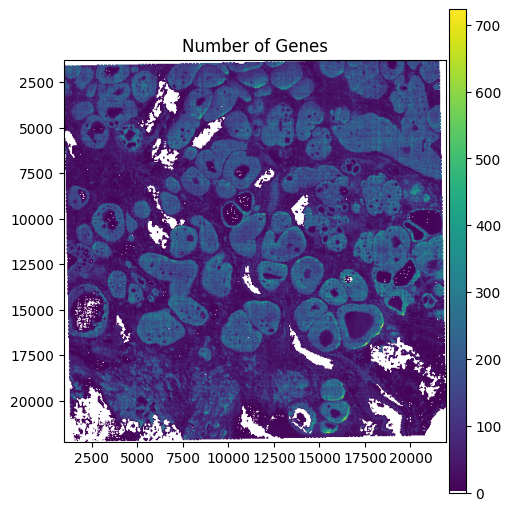

In [41]:
qp.plot_qc_metrics(sdata, "Visium_HD_Human_Breast_Cancer_FFPE", "n_genes_by_counts", bin_size = 8, figsize=(5,5), title = "Number of Genes")

Global QC Plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Colored = 0 / 663,857 (0.00%)


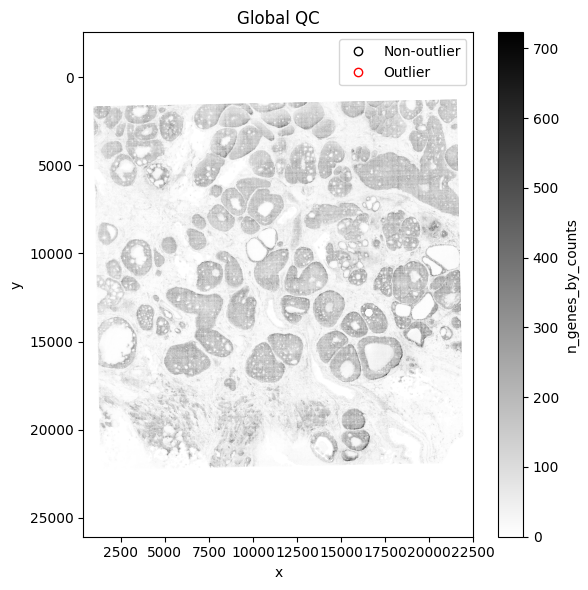

In [42]:
plot_qc_metric_with_outliers(
    adata=adata,
    sample_id="region",
    sample="Visium_HD_Human_Breast_Cancer_FFPE_square_008um",
    metric="n_genes_by_counts",
    outliers="low_genes_outlier",       # boolean column
    point_size=0.5,
    colors=("white", "black"),  # background color gradient
    stroke=0.8,
    title="Global QC"
)
plt.show()

SpotSweeper plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<module 'matplotlib.pyplot' from '/jhpce/shared/jhpce/core/python/3.9.14/lib/python3.9/site-packages/matplotlib/pyplot.py'>

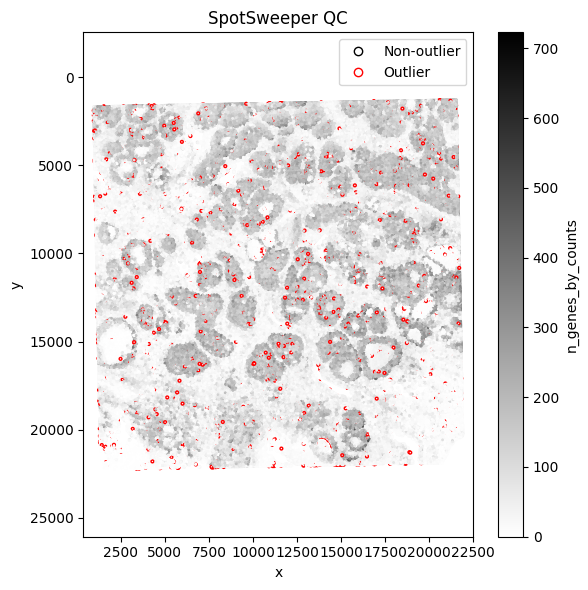

In [43]:
lo.local_outliers(adata, metric = "n_genes_by_counts", n_neighbors = 48, sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(adata,"region", metric = "n_genes_by_counts", outliers="n_genes_by_counts_outliers", title="SpotSweeper QC", legend=True, ring_overlay=False) # plot outliers

In [44]:
col = "n_genes_by_counts_outliers"
print(adata.obs[col].value_counts())

n_genes_by_counts_outliers
False    656630
True       7227
Name: count, dtype: int64


Flagged percentage: 7227/(656630+7227) = 1.09%

**% mitochondrial counts**

Spotplot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using 'datashader' backend with 'max' as reduction method to speed up plotting. Depending on the reduction
         method, the value range of the plot might change. Set method to 'matplotlib' do disable this behaviour.   


/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using the datashader reduction "max". "max" will give an output very close to the matplotlib result.      
INFO     alpha component of given RGBA value for outline color is discarded, because outline_alpha takes precedent.


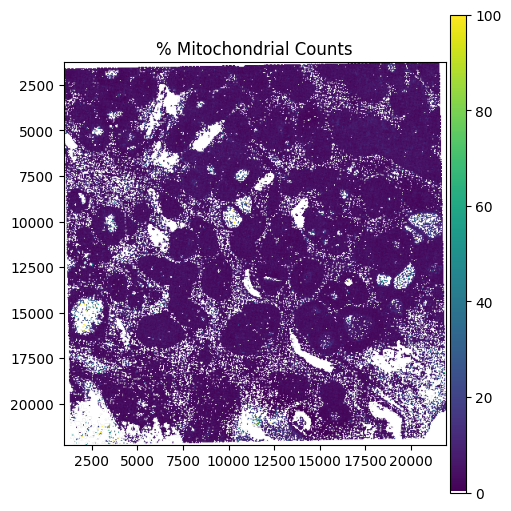

In [45]:
qp.plot_qc_metrics(sdata, "Visium_HD_Human_Breast_Cancer_FFPE", "pct_counts_mt", bin_size = 8, figsize=(5,5), title = "% Mitochondrial Counts")

Global QC Plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Colored = 27,234 / 663,857 (4.10%)


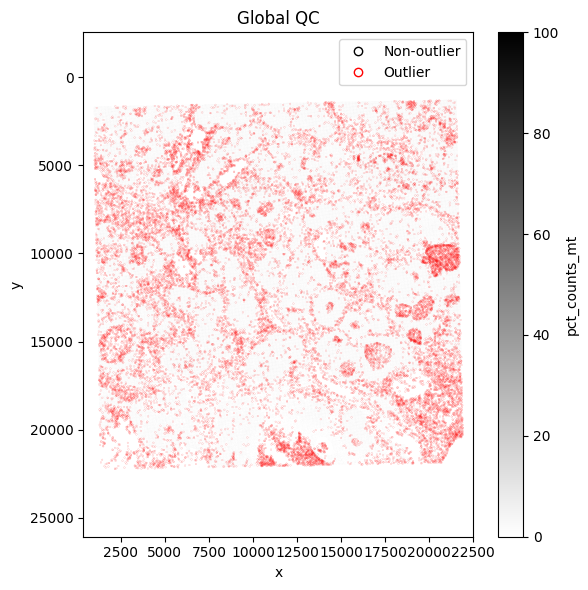

In [46]:
plot_qc_metric_with_outliers(
    adata=adata,
    sample_id="region",
    sample="Visium_HD_Human_Breast_Cancer_FFPE_square_008um",
    metric="pct_counts_mt",
    outliers="high_mt_outlier",       # boolean column
    point_size=0.1,
    colors=("white", "black"),  # background color gradient
    stroke=0.8,
    title="Global QC"
)
plt.show()

SpotSweeper plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<module 'matplotlib.pyplot' from '/jhpce/shared/jhpce/core/python/3.9.14/lib/python3.9/site-packages/matplotlib/pyplot.py'>

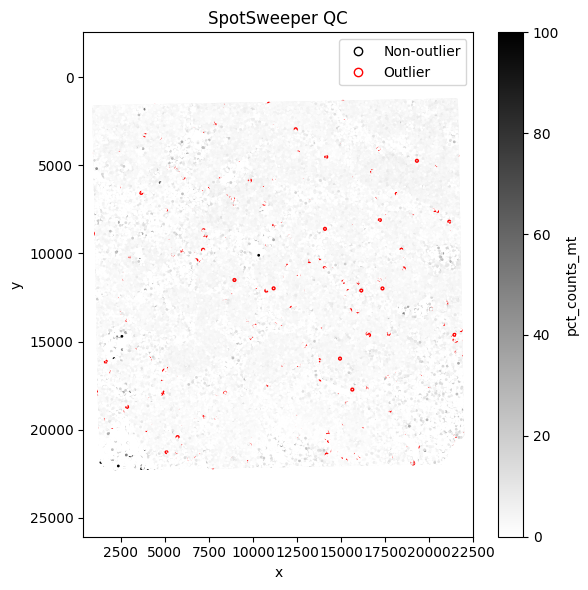

In [47]:
lo.local_outliers(adata, metric = "pct_counts_mt", direction="higher", n_neighbors = 48, sample_key = "region")
plot_QC.plot_qc_metrics(adata,"region", metric = "pct_counts_mt", outliers="pct_counts_mt_outliers", title="SpotSweeper QC", legend=True, ring_overlay=False) # plot outliers

In [48]:
col = "pct_counts_mt_outliers"
print(adata.obs[col].value_counts())

pct_counts_mt_outliers
False    662376
True       1481
Name: count, dtype: int64


Flagged percentage: 1481/(662376+1481) = 0.22%

**Violin Plots based on Local z-scores**

Global Outlier Violin Plots:

/tmp/ipykernel_255447/387015835.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/387015835.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/387015835.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/387015835.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)


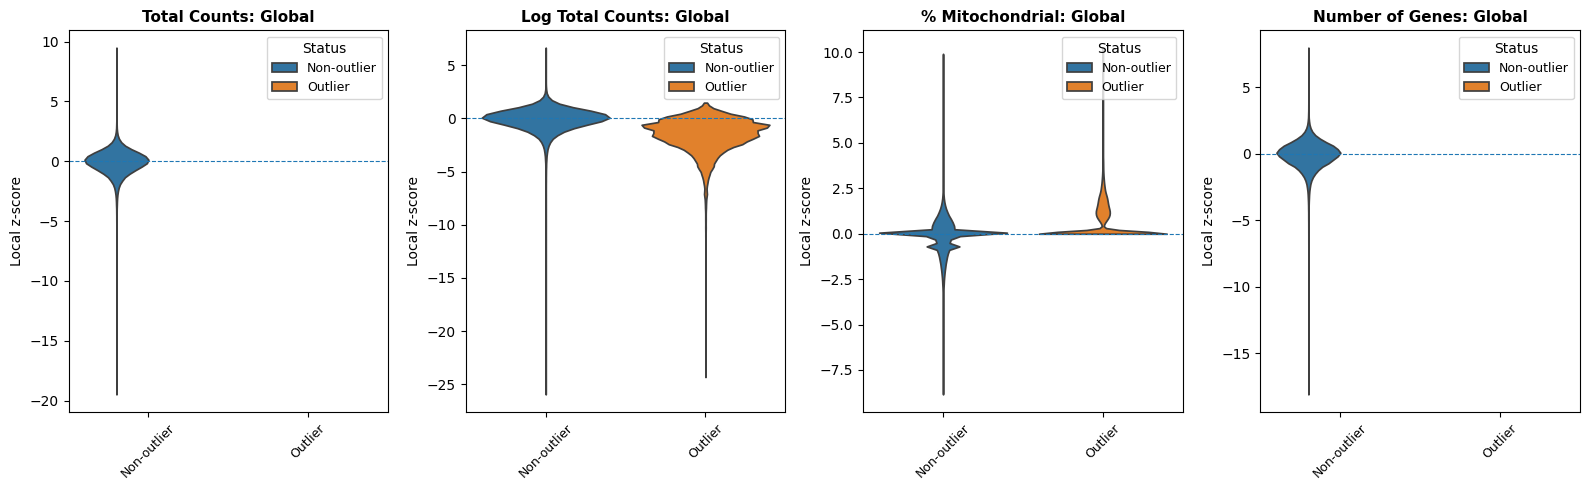

In [49]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

adata.var_names_make_unique()

for col in ['low_counts_outlier', 'low_log_counts_outlier', 'high_mt_outlier', 'low_genes_outlier']:
    adata.obs[col] = pd.Categorical(adata.obs[col], categories=[False, True])

# Map from raw metric to its *local z-scored* version in adata.obs
metric_map = {
    'total_counts': 'total_counts_z',
    'log_total_counts': 'log_total_counts_z',
    'pct_counts_mt': 'pct_counts_mt_z',
    'n_genes_by_counts': 'n_genes_by_counts_z',
}

# (z-scored metric obs key, flag, readable title, y-axis label)
pairs = [
    (metric_map['total_counts'],       'low_counts_outlier',
     'Total Counts: Global',       'Local z-score'),
    (metric_map['log_total_counts'],   'low_log_counts_outlier',
     'Log Total Counts: Global',   'Local z-score'),
    (metric_map['pct_counts_mt'],      'high_mt_outlier',
     '% Mitochondrial: Global',    'Local z-score'),
    (metric_map['n_genes_by_counts'],  'low_genes_outlier',
     'Number of Genes: Global',    'Local z-score')
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, flag, title, ylabel) in zip(axes, pairs):
    sc.pl.violin(
        adata,
        keys=metric, # local z-scored metrics
        groupby=flag,
        jitter=0.4,
        stripplot=False,
        rotation=45,
        multi_panel=False,
        ax=ax,
        show=False
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)

    # Replace generic x-axis tick labels (True/False -> Outlier/Non-Outlier)
    ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)

    # Replace legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, ['Non-outlier', 'Outlier'],
                  title="Status", loc='upper right',
                  fontsize=9, title_fontsize=10)

    # add horizontal line at 0
    ax.axhline(0, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()


Local Outlier Violin Plots:

/tmp/ipykernel_255447/735354371.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/735354371.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/735354371.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/735354371.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)


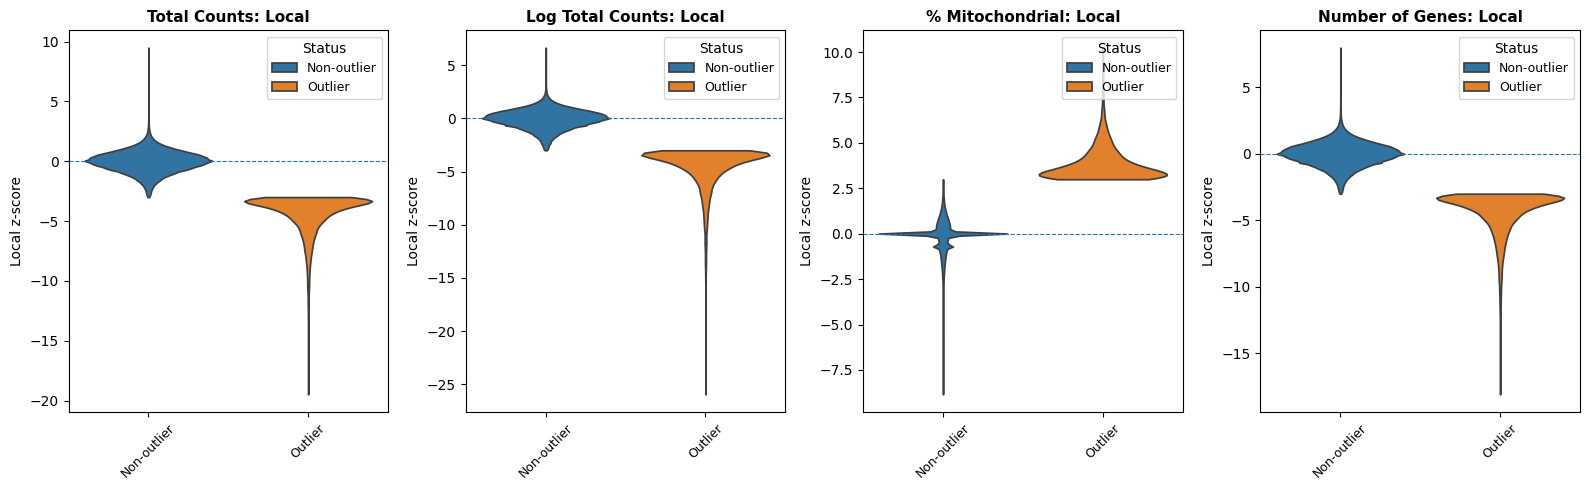

In [50]:
adata.var_names_make_unique()

# Ensure boolean -> categorical with consistent ordering
for col in ['total_counts_outliers', 'log_total_counts_outliers',
            'n_genes_by_counts_outliers', 'pct_counts_mt_outliers']:
    adata.obs[col] = pd.Categorical(adata.obs[col], categories=[False, True])

# Map raw metric -> local z-scored metric
metric_map = {
    'total_counts': 'total_counts_z',
    'log_total_counts': 'log_total_counts_z',
    'pct_counts_mt': 'pct_counts_mt_z',
    'n_genes_by_counts': 'n_genes_by_counts_z',
}

# (z-metric, local-flag, plot title)
pairs = [
    (metric_map['total_counts'],      'total_counts_outliers',      'Total Counts: Local'),
    (metric_map['log_total_counts'],  'log_total_counts_outliers',  'Log Total Counts: Local'),
    (metric_map['pct_counts_mt'],     'pct_counts_mt_outliers',     '% Mitochondrial: Local'),
    (metric_map['n_genes_by_counts'], 'n_genes_by_counts_outliers', 'Number of Genes: Local'),
]

# Create figure
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, flag, title) in zip(axes, pairs):
    sc.pl.violin(
        adata,
        keys=metric,  # use local z-score metrics
        groupby=flag,  
        jitter=0.4,
        stripplot=False,
        rotation=45,
        multi_panel=False,
        ax=ax,
        show=False
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Local z-score", fontsize=10)

    # Cleaner X-axis
    ax.set_xlabel("")
    ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)

    # Replace legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            handles,
            ['Non-outlier', 'Outlier'],
            title="Status",
            loc='upper right',
            fontsize=9,
            title_fontsize=10
        )

    # Reference line
    ax.axhline(0, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

Calculation of "Any metric flagged" for local column in the table:

In [64]:
outlier_cols = [c for c in adata.obs.columns if c.endswith("_outliers")]
adata.obs["any_local_metric_outlier"] = adata.obs[outlier_cols].any(axis=1)
flagged = adata.obs["any_local_metric_outlier"].sum()
total = adata.n_obs
pct = flagged / total * 100

print(f"Any-metric outlier: {flagged}/{total} spots ({pct:.2f}%)")

Any-metric outlier: 12173/663857 spots (1.83%)


Additional Investigation: Are all local outliers also global outliers?

In [65]:
global_flag = adata.obs["all_metrics_outlier"].astype(bool)
local_flag  = adata.obs["any_local_metric_outlier"].astype(bool)
local_subset_global = ((local_flag & ~global_flag).sum() == 0)
print("Are ALL local outliers also global outliers?:", local_subset_global)


local_not_global = (local_flag & ~global_flag).sum()
print("Local but NOT global:", local_not_global)

pd.crosstab(global_flag, local_flag,
                  rownames=["Global"], colnames=["Local"])

Are ALL local outliers also global outliers?: False
Local but NOT global: 8862


Local,False,True
Global,,
False,614241,8862
True,37443,3311


We iterate on the **2um** bins. The violin plots are generated below to overview the data/outlier distribution.

In [51]:
# computing QC metrics and creating AnnData object
import visiumhd_utils.qc_plot as qp
qp.compute_qc_metrics(sdata, bin_size=2, mito_prefix="MT-")
bdata = sdata.tables["square_002um"]

In [52]:
# flag global outliers
bdata.obs['low_counts_outlier'] = is_outlier(bdata.obs['total_counts'], direction='lower')
bdata.obs['low_log_counts_outlier'] = is_outlier(bdata.obs['log_total_counts'], direction='lower')
bdata.obs['high_mt_outlier']   = is_outlier(bdata.obs['pct_counts_mt'], direction='higher')
bdata.obs['low_genes_outlier'] = is_outlier(bdata.obs['n_genes_by_counts'], direction='lower')

# combine into one global flag
bdata.obs['all_metrics_outlier'] = (
    bdata.obs['low_counts_outlier'] | bdata.obs['low_log_counts_outlier'] | bdata.obs['high_mt_outlier'] | bdata.obs['low_genes_outlier']
)

print(bdata.obs['low_counts_outlier'].value_counts())
print(bdata.obs['low_log_counts_outlier'].value_counts())
print(bdata.obs['high_mt_outlier'].value_counts())
print(bdata.obs['low_genes_outlier'].value_counts())
print(bdata.obs['all_metrics_outlier'].value_counts())

low_counts_outlier
False    10535119
Name: count, dtype: int64
low_log_counts_outlier
False    10535119
Name: count, dtype: int64
high_mt_outlier
False    9146980
True     1388139
Name: count, dtype: int64
low_genes_outlier
False    10535119
Name: count, dtype: int64
all_metrics_outlier
False    9146980
True     1388139
Name: count, dtype: int64


So at the 2um level, ONLY % mito flags outliers for global QC!

Note that the local outlier algorithm takes considerably longer time on 2um bins, and we document the time of each run below. We run each command on a compute node (CPU only) with 64G RAM.

Run-time for total counts metric (local outlier detection + plots of local outliers): 9m 32s.  
Run-time for log total counts metric: 10m 16s.  
Run-time for n genes by counts metric: 9m 16s.  
Run-time for %mito metric: 10m 22s.

**Total Counts**  
Global QC does not flag any outliers.

SpotSweeper plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<module 'matplotlib.pyplot' from '/jhpce/shared/jhpce/core/python/3.9.14/lib/python3.9/site-packages/matplotlib/pyplot.py'>

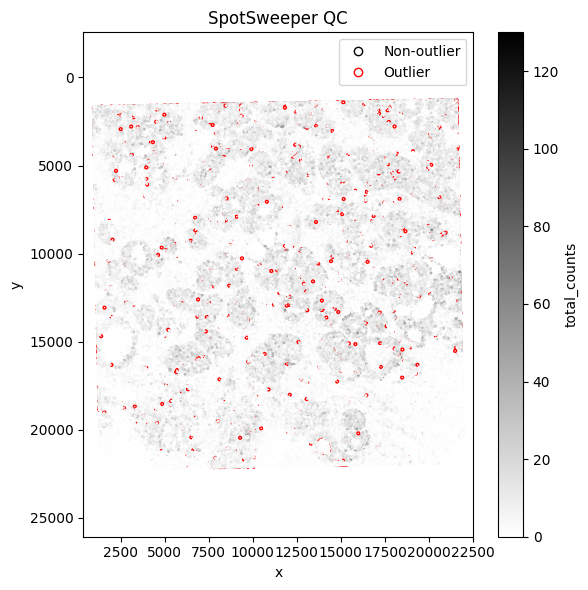

In [53]:
import spotsweeper.local_outliers as lo
import spotsweeper.plot_QC as plot_QC
# total counts
lo.local_outliers(bdata, metric = "total_counts", n_neighbors = 48, sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(bdata,"region", metric = "total_counts", outliers="total_counts_outliers", title="SpotSweeper QC", legend=True, ring_overlay=False) # plot outliers

In [54]:
col = "total_counts_outliers"
print(bdata.obs[col].value_counts())

total_counts_outliers
False    10471138
True        63981
Name: count, dtype: int64


82873/(10452246+82873) = 0.79%

**Log Total Counts**  
Global QC does not flag any outliers.

SpotSweeper plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<module 'matplotlib.pyplot' from '/jhpce/shared/jhpce/core/python/3.9.14/lib/python3.9/site-packages/matplotlib/pyplot.py'>

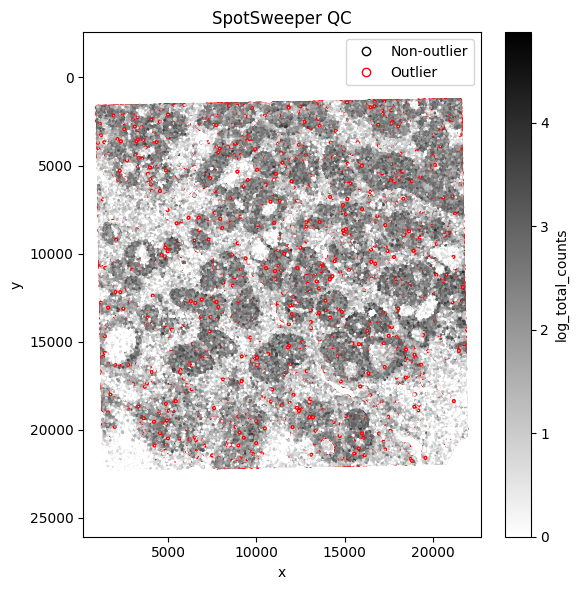

In [55]:
# log total counts
lo.local_outliers(bdata, metric = "log_total_counts", n_neighbors = 48, sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(bdata,"region", metric = "log_total_counts", outliers="log_total_counts_outliers", title = "SpotSweeper QC", legend=True, ring_overlay=False) # plot outliers

In [56]:
col = "log_total_counts_outliers"
print(bdata.obs[col].value_counts())

log_total_counts_outliers
False    10332923
True       202196
Name: count, dtype: int64


244094/(10291025+244094) = 2.3%

**Number of Genes by Counts**  
Global QC does not flag any outliers.

Spotsweeper plot:

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<module 'matplotlib.pyplot' from '/jhpce/shared/jhpce/core/python/3.9.14/lib/python3.9/site-packages/matplotlib/pyplot.py'>

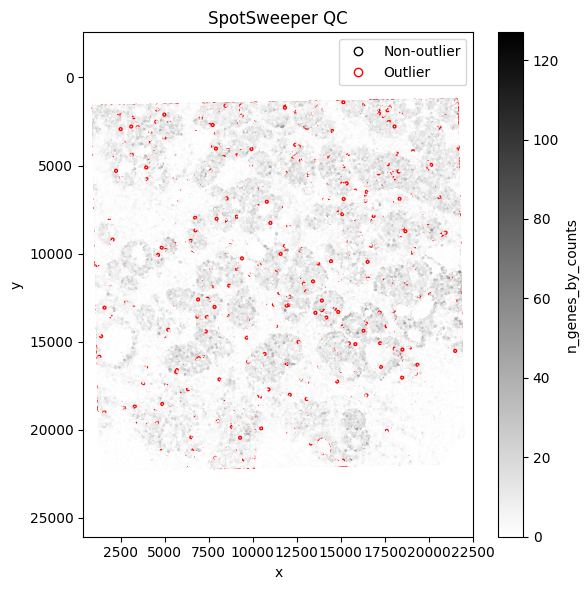

In [57]:
# n genes by counts
lo.local_outliers(bdata, metric = "n_genes_by_counts", n_neighbors = 48, sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(bdata,"region", metric = "n_genes_by_counts", outliers="n_genes_by_counts_outliers", title = "SpotSweeper QC", legend=True, ring_overlay=False) # plot outliers

In [58]:
col = "n_genes_by_counts_outliers"
print(bdata.obs[col].value_counts())

n_genes_by_counts_outliers
False    10470174
True        64945
Name: count, dtype: int64


83765/(10451354+83765) = 0.8%

**% Mitochondrial Counts**

SpotSweeper plot: (Interesting that it flags MINIMAL outliers!)

/users/xchen5/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


<module 'matplotlib.pyplot' from '/jhpce/shared/jhpce/core/python/3.9.14/lib/python3.9/site-packages/matplotlib/pyplot.py'>

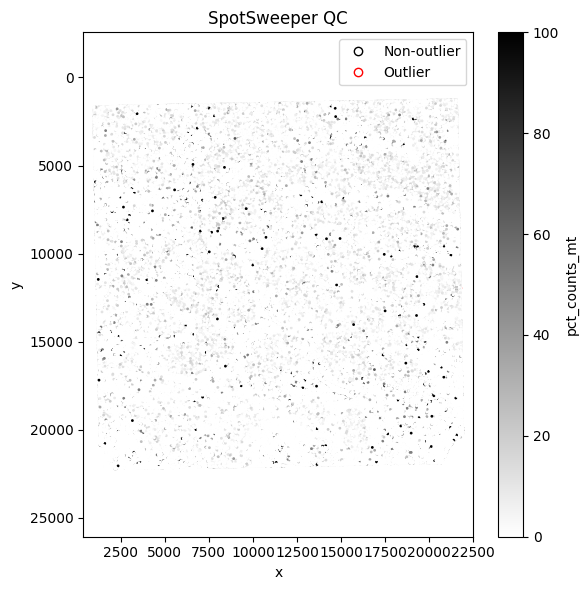

In [59]:
# % mito
lo.local_outliers(bdata, metric = "pct_counts_mt", direction = "higher", n_neighbors = 48, sample_key = "region") # compute local outliers
plot_QC.plot_qc_metrics(bdata,"region", metric = "pct_counts_mt", outliers="pct_counts_mt_outliers", title = "SpotSweeper QC", legend=True, ring_overlay=False) # plot outliers

In [60]:
col = "pct_counts_mt_outliers"
print(bdata.obs[col].value_counts())

pct_counts_mt_outliers
False    10535044
True           75
Name: count, dtype: int64


192/(10534927+192) = 0.002%

**Violin Plots based on Local z-scores:**

Global outlier violin plots:

/tmp/ipykernel_255447/3328307629.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/3328307629.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/3328307629.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/3328307629.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)


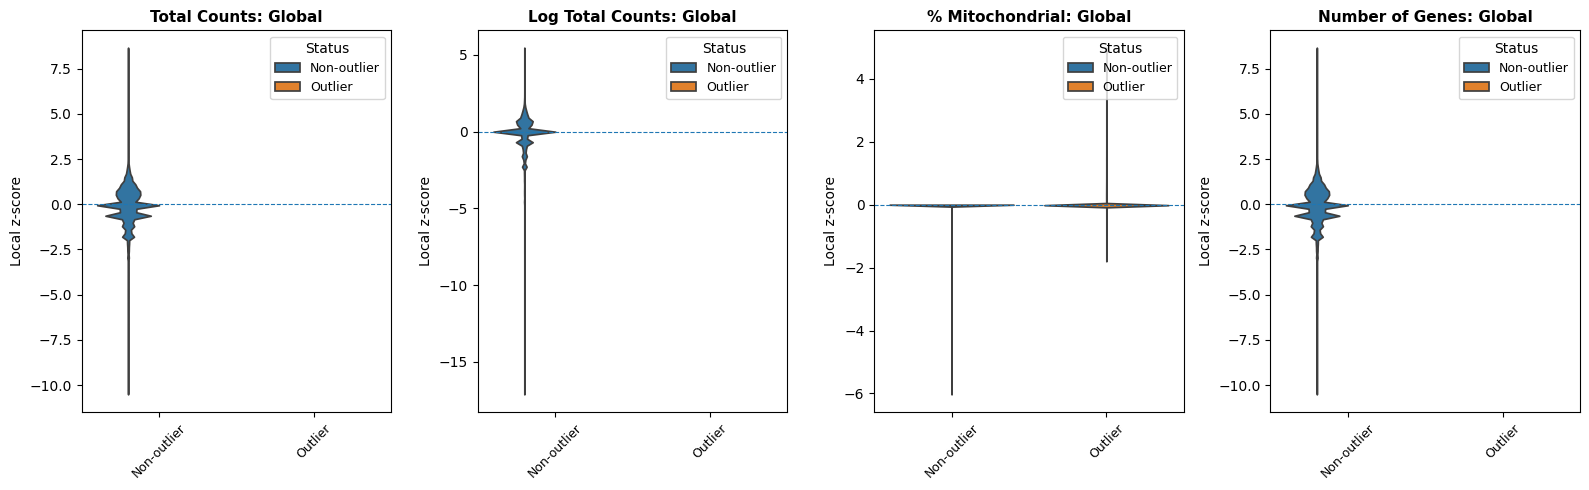

In [61]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

bdata.var_names_make_unique()

for col in ['low_counts_outlier', 'low_log_counts_outlier', 'high_mt_outlier', 'low_genes_outlier']:
    bdata.obs[col] = pd.Categorical(bdata.obs[col], categories=[False, True])

# Map from raw metric to its *local z-scored* version in adata.obs
metric_map = {
    'total_counts': 'total_counts_z',
    'log_total_counts': 'log_total_counts_z',
    'pct_counts_mt': 'pct_counts_mt_z',
    'n_genes_by_counts': 'n_genes_by_counts_z',
}

# (z-scored metric obs key, flag, readable title, y-axis label)
pairs = [
    (metric_map['total_counts'],       'low_counts_outlier',
     'Total Counts: Global',       'Local z-score'),
    (metric_map['log_total_counts'],   'low_log_counts_outlier',
     'Log Total Counts: Global',   'Local z-score'),
    (metric_map['pct_counts_mt'],      'high_mt_outlier',
     '% Mitochondrial: Global',    'Local z-score'),
    (metric_map['n_genes_by_counts'],  'low_genes_outlier',
     'Number of Genes: Global',    'Local z-score')
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, flag, title, ylabel) in zip(axes, pairs):
    sc.pl.violin(
        bdata,
        keys=metric, # local z-scored metrics
        groupby=flag,
        jitter=0.4,
        stripplot=False,
        rotation=45,
        multi_panel=False,
        ax=ax,
        show=False
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)

    # Replace generic x-axis tick labels (True/False -> Outlier/Non-Outlier)
    ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)

    # Replace legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, ['Non-outlier', 'Outlier'],
                  title="Status", loc='upper right',
                  fontsize=9, title_fontsize=10)

    # add horizontal line at 0
    ax.axhline(0, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

Local outlier violin plots:

/tmp/ipykernel_255447/1964362369.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/1964362369.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/1964362369.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)
/tmp/ipykernel_255447/1964362369.py:44: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)


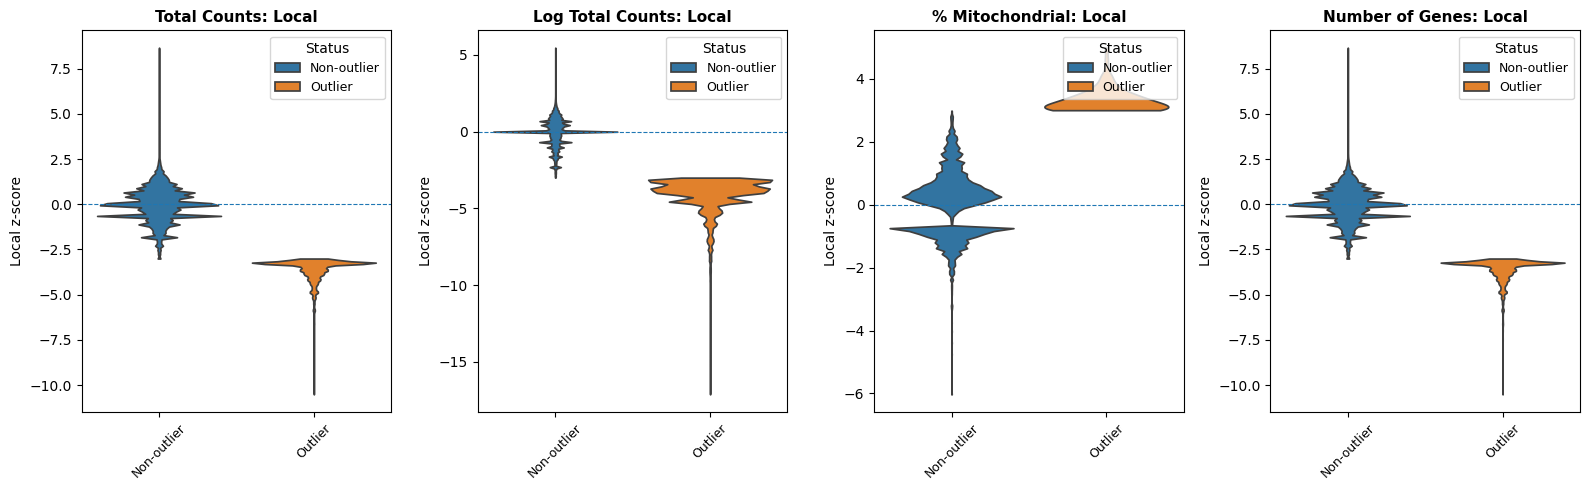

In [62]:
bdata.var_names_make_unique()

# Ensure boolean -> categorical with consistent ordering
for col in ['total_counts_outliers', 'log_total_counts_outliers',
            'n_genes_by_counts_outliers', 'pct_counts_mt_outliers']:
    bdata.obs[col] = pd.Categorical(bdata.obs[col], categories=[False, True])

# Map raw metric -> local z-scored metric
metric_map = {
    'total_counts': 'total_counts_z',
    'log_total_counts': 'log_total_counts_z',
    'pct_counts_mt': 'pct_counts_mt_z',
    'n_genes_by_counts': 'n_genes_by_counts_z',
}

# (z-metric, local-flag, plot title)
pairs = [
    (metric_map['total_counts'],      'total_counts_outliers',      'Total Counts: Local'),
    (metric_map['log_total_counts'],  'log_total_counts_outliers',  'Log Total Counts: Local'),
    (metric_map['pct_counts_mt'],     'pct_counts_mt_outliers',     '% Mitochondrial: Local'),
    (metric_map['n_genes_by_counts'], 'n_genes_by_counts_outliers', 'Number of Genes: Local'),
]

# Create figure
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, flag, title) in zip(axes, pairs):
    sc.pl.violin(
        bdata,
        keys=metric,  # use local z-score metrics
        groupby=flag,  
        jitter=0.4,
        stripplot=False,
        rotation=45,
        multi_panel=False,
        ax=ax,
        show=False
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Local z-score", fontsize=10)

    # Cleaner X-axis
    ax.set_xlabel("")
    ax.set_xticklabels(['Non-outlier', 'Outlier'], fontsize=9)

    # Replace legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            handles,
            ['Non-outlier', 'Outlier'],
            title="Status",
            loc='upper right',
            fontsize=9,
            title_fontsize=10
        )

    # Reference line
    ax.axhline(0, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

In [66]:
# write into .h5ad files for future usage
adata.write("/users/xchen5/hd8um.h5ad")
bdata.write("/users/xchen5/hd2um.h5ad")